# Relations II - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-2/relations-2.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Reflexive, Symmetric, Transitive
(Several arrow diagrams for the examples.)

Let the set $A = \{0,1,2,3\}$. Define the relation
$$
    R = \{(0,0),(0,1),(0,3),(1,0),(1,1),(2,2),(3,0),(3,3)\}. 
$$
It has the following arrow diagram.

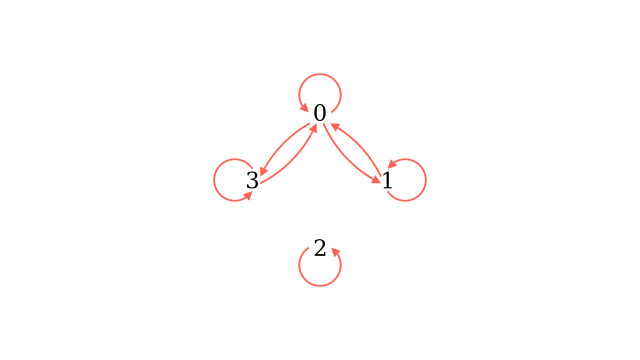

In [25]:
%%generate_image rst_1 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*DOWN),
            (0, 3): ((1.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*UP),
            (1, 0): ((0.5*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*RIGHT),
            (3, 0): ((0.5*ARROW_START_SHIFT)*DOWN, (0.5*ARROW_START_SHIFT)*LEFT)
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

Let the set $A = \{0,1,2,3\}$. Define the relation
$$
    S = \{(0,0),(0,2),(0,3),(2,3)\}
$$
on $A$, which has the following arrow diagram.

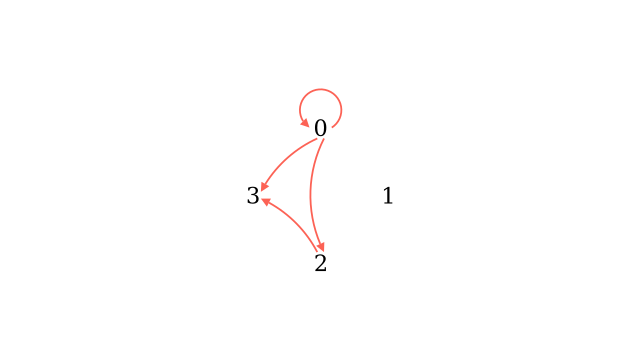

In [26]:
%%generate_image rst_2 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 2): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*RIGHT),
            (0, 3): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*UP),
            (2, 3): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*DOWN),
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

### Equivalence Relations

Consider $A = \{0, 1, 2, 3\}$ and define a relation $R$ on $A$ by
$$
    R = \{(0,0), (1,1), (2,2), (3,3)\}
$$

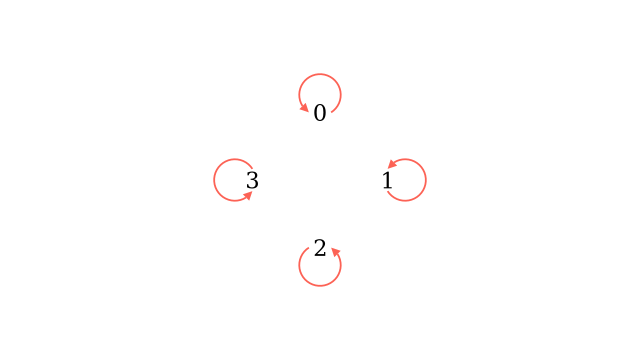

In [17]:
%%generate_image equiv-rel_1 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {}  # Nothing :p
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)

Consider $A = \{0, 1, 2, 3\}$ and define a relation $R$ on $A$ by
$$
    \begin{align*}
        R &= \{(0, 0), (0, 1), (0, 2), (1, 0), (1, 1),\\
        &\quad\quad(1, 2), (2, 0), (2, 1), (2, 2), (3, 3)\}
    \end{align*}
$$

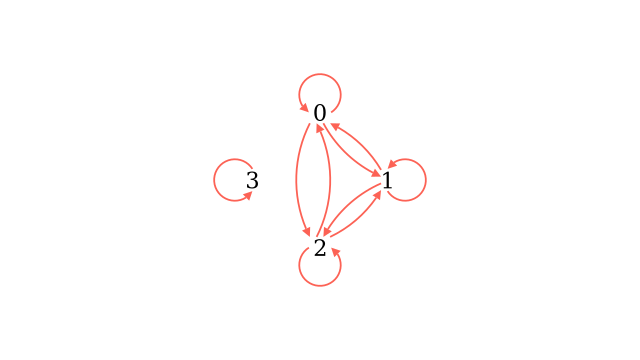

In [16]:
%%generate_image equiv-rel_2 RelationDiagram
    
FONT_SIZE = 36

RADIUS = 1.5  # Radius of square/diamond

ELEMENT_POS_SHIFT = 0.05
ARROW_STROKE_WIDTH = 4
ARROW_START_SHIFT = 0.15
ARROW_TIP_SIZE = 0.2


class RelationDiagram(Scene):
    def construct(self):
        # Create elements
        elements = ["0", "1", "2", "3"]
        elements = [Text(elem, font_size=FONT_SIZE, color=BLACK) for elem in elements]
        arrange_circular(*elements, clockwise=True, radius=RADIUS)
        
        # Determine element positions
        element_reference_position = {
            0: elements[0].get_bottom() + ELEMENT_POS_SHIFT*DOWN,
            1: elements[1].get_left() + ELEMENT_POS_SHIFT*LEFT,
            2: elements[2].get_top() + ELEMENT_POS_SHIFT*UP,
            3: elements[3].get_right() + ELEMENT_POS_SHIFT*RIGHT,
        }

        # Add elements to a group
        elements = VGroup(*elements)

        # Create arrows
        reflexive_arrows = [
            Arc(arc_center=elements[0].get_center() + 0.25*UP, start_angle=-np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[1].get_center() + 0.25*RIGHT, start_angle=-3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[2].get_center() + 0.25*DOWN, start_angle=3*np.pi/4, angle=3*np.pi/2, radius=0.35),
            Arc(arc_center=elements[3].get_center() + 0.25*LEFT, start_angle=np.pi/4, angle=3*np.pi/2, radius=0.35),
        ]

        inter_element_relations = {
            (0, 1): ((0.5*ARROW_START_SHIFT)*RIGHT, (0.5*ARROW_START_SHIFT)*UP),
            (0, 2): ((1.5*ARROW_START_SHIFT)*LEFT, (1.5*ARROW_START_SHIFT)*LEFT),
            (1, 0): ((1.5*ARROW_START_SHIFT)*UP, (1.5*ARROW_START_SHIFT)*RIGHT),
            (1, 2): ((0.5*ARROW_START_SHIFT)*DOWN, (0.5*ARROW_START_SHIFT)*RIGHT),
            (2, 0): ((0.5*ARROW_START_SHIFT)*LEFT, (0.5*ARROW_START_SHIFT)*LEFT),
            (2, 1): ((1.5*ARROW_START_SHIFT)*RIGHT, (1.5*ARROW_START_SHIFT)*DOWN)
        }
        inter_element_arrows = [
            ArcBetweenPoints(
                element_reference_position[i] + adj_i,
                element_reference_position[j] + adj_j,
                radius = 3
            )
            for (i, j), (adj_i, adj_j) in inter_element_relations.items()
        ]
        arrows = [*reflexive_arrows, *inter_element_arrows]

        for arrow in arrows:
            arrow.set_color(RED)
            arrow.add_tip(tip_length=ARROW_TIP_SIZE, tip_width=ARROW_TIP_SIZE)

        arrows = VGroup(*arrows)

        # Add all elements to the scene
        group = Group(elements, arrows)
        group.center()
        self.add(group)